In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Q1: Loading and Understanding the Dataset

In [16]:
#Q1.1: Load dataset
data = sns.load_dataset('tips')

In [17]:
#Q1.2: Display first rows
data.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
#Q1.3: Dataset shape and columns
print(data.shape)
print(data.columns)

(244, 7)
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


# Q2: Basic Filtering – Who Tips More?

In [19]:
#Q2.1: Weekend
weekend = data[data['day'].isin(['Sat', 'Sun'])]
weekdays = data[~data['day'].isin(['Sat', 'Sun'])]

In [20]:
#Q2.2:Average tip, Average total bill
weekend_avg = weekend['tip'].mean()
weekdays_avg = weekdays['tip'].mean()

weekend_total = weekend['total_bill'].mean()
weekdays_total = weekdays['total_bill'].mean()

# Q2.3: Compare this with weekday customers.
compare = pd.DataFrame({
    'Avg Tip: ': [weekend_avg, weekdays_avg],
    'Total bill': [weekend_total, weekdays_total]
}, index=['Weekend', 'Weekday'])
compare

,Avg Tip:,Total bill
Weekend,3.115276,20.893006
Weekday,2.762840,17.558148


# Q3: Sorting and Identifying High-Value Customers

In [21]:
# Q3.1: Sort customers by total_bill (descending).
data.sort_values(by='total_bill', ascending=False)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
...,...,...,...,...,...,...,...
149,7.51,2.00,Male,No,Thur,Lunch,2
172,7.25,5.15,Male,Yes,Sun,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2


In [22]:
# Q3.2:Display the top 10 highest bills.
data.sort_values(by='total_bill', ascending=False).head(10)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
102,44.30,2.50,Female,Yes,Sat,Dinner,3
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
184,40.55,3.00,Male,Yes,Sun,Dinner,2
95,40.17,4.73,Male,Yes,Fri,Dinner,4


In [23]:
data.sort_values(by='total_bill', ascending=True).head(10)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2
195,7.56,1.44,Male,No,Thur,Lunch,2
218,7.74,1.44,Male,Yes,Sat,Dinner,2
145,8.35,1.50,Female,No,Thur,Lunch,2
135,8.51,1.25,Female,No,Thur,Lunch,2
126,8.52,1.48,Male,No,Thur,Lunch,2


In [24]:
# Q3.3: What do you notice about their group sizes?
# I create one more code to understanding the difference about sizes, customers who have more total 
# bills usually come in larger group than who have less total bills

# Q4: Data Quality Check & Cleaning

In [25]:
#Q4.1: missing values
data.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Q4.2: Why missing values are dangerous in machine learning
Because models can create break assumptions about data, for example if values missing then our model learns a wrong way or learn distorted picture.

# Q5: Visualization – What Influences Tips?

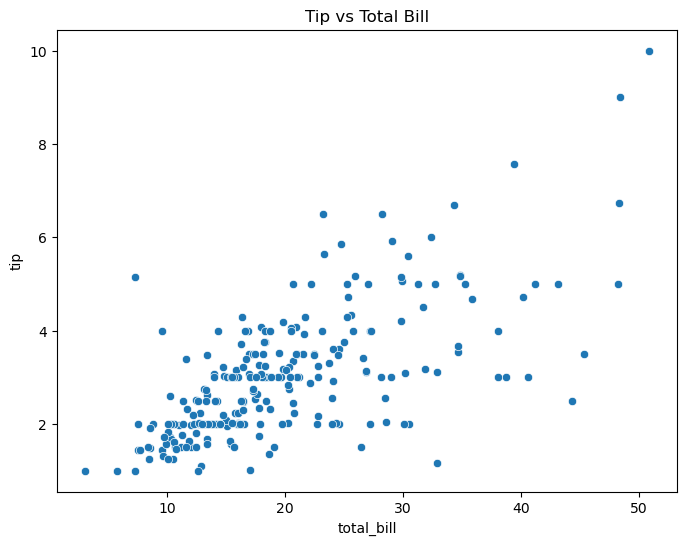

In [26]:
#Q5.1: Tip vs Total Bill (scatter plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='total_bill', y='tip')
plt.title('Tip vs Total Bill')
plt.show()

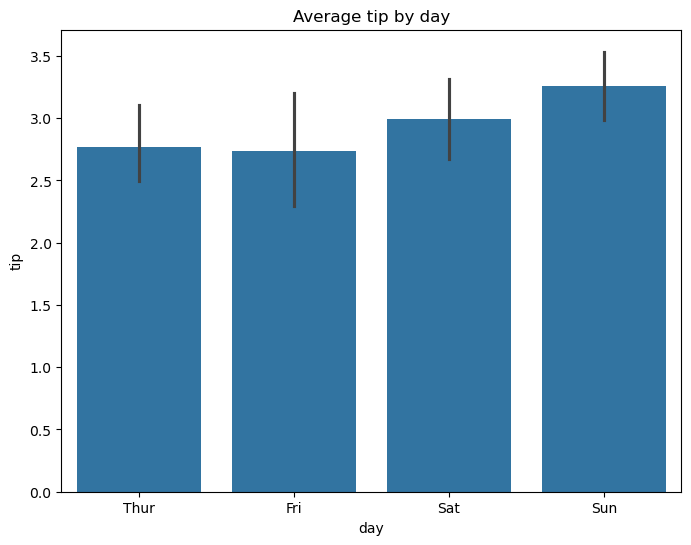

In [27]:
# Q5.1: Average tip by day (bar plot)
plt.figure(figsize=(8,6))
sns.barplot(data=data, x='day', y='tip', estimator='mean')
plt.title('Average tip by day')
plt.show()

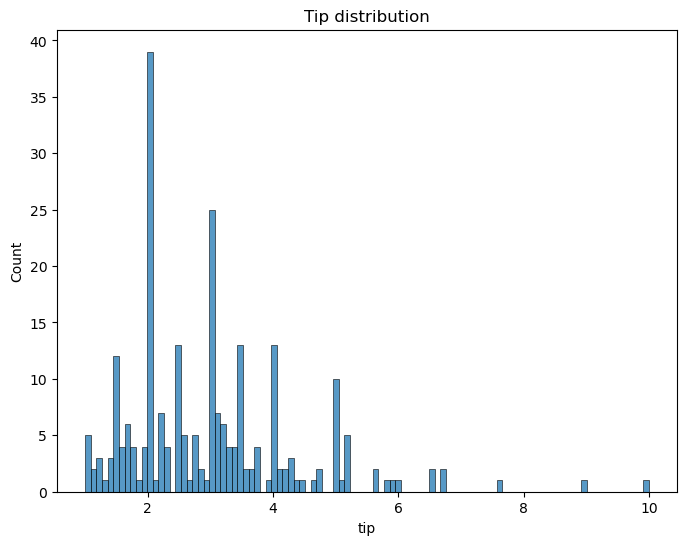

In [28]:
# Q5.1: Tip distribution (histogram)
plt.figure(figsize=(8,6))
sns.histplot(data['tip'], bins=100)
plt.title('Tip distribution')
plt.show()

### Q5.2: Interpret each plot in 1–2 sentences.
The first plot shows that tips generally increase as total bills increase, it is mean that who have more orders that leave more tips. In second plot we get that we earn more tips in Sunday, this suggests that more people visit or tip more generously on weekends. The third plot shows that most tips are between 2 and 4.

# Q6: Final Insight & Conclusion (25 marks)

### Who tips more?
People who spend more usually tip more.
### When tips are highest?
On weekends, tips and total bills are generally higher.
### How this insight could help restaurant management.
With this insight, restaurant management can plan better staffing, promotions, or special offers on weekends to maximize sales and tips.
And also the gender of customers and whether they are smokers or not does not have a significant impact on tips.

In [31]:
cust_sort = data.sort_values('total_bill', ascending=False)
cust_sort

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
...,...,...,...,...,...,...,...
149,7.51,2.00,Male,No,Thur,Lunch,2
172,7.25,5.15,Male,Yes,Sun,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
